# Adversarial Drift Detection — Instance-Based Poisoning

Reproduces the instance-based poisoning experiment from:
> Kuppa & Le-Khac (2022) *"Learn to adapt: Robust drift detection in security domain."*

Mirrors `normal_drift_baseline.ipynb` **exactly**, with one controlled difference:
before each detector is retrained, the training set is poisoned at ratio $L_{inst}$.

**Controlled variable**: training data is poisoned at $L_{inst} \in \{0.00, 0.05, \ldots, 0.25\}$
before each retrain. $L_{inst}$ = fraction of training set size injected in total.
Accuracy drop = F1(clean) − F1(poisoned).

## 1. Imports & Configuration

In [ ]:
import os
import sys
from concurrent.futures import ThreadPoolExecutor

sys.path.insert(0, os.path.abspath('../..'))

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from src.detectors.contrastive_ncm import (
    ContrastiveNCMDetector,
    DriftAutoencoder,
    NCMClassifier,
    train_plain_autoencoder,
)

DATA_DIR    = os.path.abspath('../../data/CICIDS2017_Engelen')
EPOCHS      = 300
LR          = 0.0001
BATCH_SIZE  = 4096
TEST_SIZE   = 0.25
RANDOM_SEED = 42
DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

torch.set_float32_matmul_precision('high')

DROPPED_CLASSES  = ['DoS', 'Patator']
SURROGATE_EPOCHS = 300
PGD_EPSILON      = 0.3
PGD_ALPHA        = 0.01
PGD_STEPS        = 20
N_BAGS           = 5
INJECTION_RATIOS = [0.00, 0.05, 0.10, 0.15, 0.20, 0.25]

print(f'Device         : {DEVICE}')
print(f'Dropped classes: {DROPPED_CLASSES}')

Device         : cuda
Dropped classes: ['DoS', 'Patator']


## 2. Load & Preprocess

In [2]:
DAY_FILES = [
    'Monday-WorkingHours.csv',
    'Tuesday-WorkingHours.csv',
    'Wednesday-WorkingHours.csv',
    'Thursday-WorkingHours.csv',
    'Friday-WorkingHours.csv',
]

print('Loading data...')
df = pd.concat(
    [pd.read_csv(os.path.join(DATA_DIR, f)) for f in DAY_FILES],
    ignore_index=True,
)
print(f'  Total rows: {len(df):,}')

df.drop(columns=['Flow ID', 'Src IP', 'Src Port', 'Dst IP', 'Dst Port', 'Timestamp'],
        inplace=True, errors='ignore')
df['Label'] = df['Label'].apply(lambda x: 'BENIGN' if x.endswith('- Attempted') else x)
df['Label'] = df['Label'].replace({
    'DoS Hulk': 'DoS', 'DoS GoldenEye': 'DoS',
    'DoS slowloris': 'DoS', 'DoS Slowhttptest': 'DoS',
    'Web Attack - Brute Force': 'Web Attack', 'Web Attack - XSS': 'Web Attack',
    'Web Attack - Sql Injection': 'Web Attack',
    'FTP-Patator': 'Patator', 'SSH-Patator': 'Patator',
})

X_raw = df[[c for c in df.columns if c != 'Label']].copy()
y_str = df['Label'].values
X_raw.replace([np.inf, -np.inf], np.nan, inplace=True)
X_raw.dropna(axis=1, how='all', inplace=True)
X_raw.fillna(X_raw.mean(), inplace=True)

X       = StandardScaler().fit_transform(X_raw).astype(np.float32)
le_full = LabelEncoder()
y_all   = le_full.fit_transform(y_str)
input_dim = X.shape[1]
print(f'Features: {input_dim}  |  Classes: {list(le_full.classes_)}')

Loading data...
  Total rows: 2,100,814
Features: 77  |  Classes: ['BENIGN', 'Bot', 'DDoS', 'DoS', 'Heartbleed', 'Infiltration', 'Patator', 'PortScan', 'Web Attack']


## 3. Helpers

In [ ]:
class GPUDataLoader:
    def __init__(self, X: torch.Tensor, y: torch.Tensor, batch_size: int, shuffle: bool = True):
        self.X, self.y, self.batch_size, self.n = X, y, batch_size, X.shape[0]
        self.shuffle = shuffle

    def __len__(self) -> int:
        return (self.n + self.batch_size - 1) // self.batch_size

    def __iter__(self):
        idx = (torch.randperm(self.n, device=self.X.device)
               if self.shuffle else torch.arange(self.n, device=self.X.device))
        for i in range(0, self.n, self.batch_size):
            b = idx[i:i + self.batch_size]
            yield self.X[b], self.y[b]


def make_loader(X_arr, y_arr, shuffle=True):
    return GPUDataLoader(
        torch.from_numpy(X_arr).to(DEVICE),
        torch.from_numpy(y_arr).to(DEVICE),
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
    )


def best_threshold(cal_dists, val_dists, val_labels, n_steps=300):
    best_f1, best_t, best_q = 0.0, 0.0, 0.0
    for q in np.linspace(0.01, 0.99, n_steps):
        t     = float(torch.quantile(cal_dists, q).item())
        preds = (val_dists > t).numpy().astype(int)
        f1    = f1_score(val_labels, preds, zero_division=0)
        if f1 > best_f1:
            best_f1, best_t, best_q = f1, t, q
    return best_t, best_q * 100


def evaluate(dists, y_true, threshold):
    preds = (dists > threshold).numpy().astype(int)
    return (
        precision_score(y_true, preds, zero_division=0),
        recall_score(y_true, preds, zero_division=0),
        f1_score(y_true, preds, zero_division=0),
    )

## 4. Split & Build Evaluation Sets

In [ ]:
dropped_ids = np.array([le_full.transform([c])[0] for c in DROPPED_CLASSES])

X_tr_raw, X_te, y_tr_raw, y_te = train_test_split(
    X, y_all, test_size=TEST_SIZE, random_state=RANDOM_SEED, stratify=y_all
)

train_known_mask = ~np.isin(y_tr_raw, dropped_ids)
X_tr_known       = X_tr_raw[train_known_mask]
y_tr_known_orig  = y_tr_raw[train_known_mask]

le_train   = LabelEncoder()
y_tr_reenc = le_train.fit_transform(y_tr_known_orig).astype(np.int64)
n_classes  = len(le_train.classes_)

X_fit, X_cal_arr, y_fit, _ = train_test_split(
    X_tr_known, y_tr_reenc, test_size=0.10,
    random_state=RANDOM_SEED, stratify=y_tr_reenc,
)
X_cal = torch.from_numpy(X_cal_arr)

X_tr_novel = X_tr_raw[~train_known_mask]

rng     = np.random.default_rng(RANDOM_SEED)
pos_idx = np.where(np.isin(y_te, dropped_ids))[0]
neg_idx = np.where(~np.isin(y_te, dropped_ids))[0]
bal_idx = np.concatenate([pos_idx, rng.choice(neg_idx, size=len(pos_idx), replace=False)])
y_bin   = np.isin(y_te[bal_idx], dropped_ids).astype(int)

val_idx, held_idx = train_test_split(
    np.arange(len(bal_idx)), test_size=0.5, random_state=RANDOM_SEED, stratify=y_bin
)
X_val  = torch.from_numpy(X_te[bal_idx][val_idx])
y_val  = y_bin[val_idx]
X_held = torch.from_numpy(X_te[bal_idx][held_idx])
y_held = y_bin[held_idx]

print(f'Dropped classes  : {DROPPED_CLASSES}')
print(f'Training classes : {n_classes}  -> {[le_full.classes_[i] for i in le_train.classes_]}')
print(f'Fit samples      : {len(X_fit):,}')
print(f'Calibration      : {len(X_cal_arr):,}')
print(f'Novel train pool : {len(X_tr_novel):,}  (attacker poison pool)')
print(f'Val samples      : {len(X_val):,}  (balanced)')
print(f'Held-out samples : {len(X_held):,}  (balanced)')

Dropped classes  : ['DoS', 'Patator']
Training classes : 7  -> ['BENIGN', 'Bot', 'DDoS', 'Heartbleed', 'Infiltration', 'PortScan', 'Web Attack']
Fit samples      : 1,297,404
Calibration      : 144,157
Novel train pool : 134,049  (attacker poison pool)
Val samples      : 44,683  (balanced)
Held-out samples : 44,683  (balanced)


## 5. Train Surrogate & Generate Adversarial Pool

The attacker trains a plain MLP on accessible data (black-box threat model).
PGD pushes each novel-class sample toward its nearest known-class centroid,
making it appear as a known-class sample to the detector. The full poison pool
is generated once and sampled at each injection ratio.

In [ ]:
class SurrogateMLP(nn.Module):
    def __init__(self, in_dim, n_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 128), nn.ReLU(),
            nn.Linear(128, 64),     nn.ReLU(),
            nn.Linear(64, n_classes),
        )
    def forward(self, x):
        return self.net(x)


surrogate     = SurrogateMLP(input_dim, n_classes).to(DEVICE)
surrogate_opt = torch.optim.Adam(surrogate.parameters(), lr=LR)
ce_loss       = nn.CrossEntropyLoss()

print('Training surrogate...')
surrogate_loader = make_loader(X_fit, y_fit)
surrogate.train()
for epoch in range(SURROGATE_EPOCHS):
    epoch_loss = 0.0
    for x_b, y_b in surrogate_loader:
        surrogate_opt.zero_grad()
        loss = ce_loss(surrogate(x_b), y_b)
        loss.backward()
        surrogate_opt.step()
        epoch_loss += loss.item()
    if (epoch + 1) % 25 == 0 or epoch == 0 or epoch == SURROGATE_EPOCHS - 1:
        print(f'  epoch {epoch+1}/{SURROGATE_EPOCHS}  loss={epoch_loss/len(surrogate_loader):.4f}')
surrogate.eval()
print('Surrogate ready.')

MAX_POOL = 10_000
rng_pool = np.random.RandomState(RANDOM_SEED)
pool_idx = rng_pool.choice(len(X_tr_novel), size=min(MAX_POOL, len(X_tr_novel)), replace=False)
X_novel_pool = X_tr_novel[pool_idx]
print(f'Novel pool: {len(X_novel_pool):,} samples (subsampled from {len(X_tr_novel):,})')

centroids      = np.stack([X_fit[y_fit == c].mean(axis=0) for c in range(n_classes)])
dists_c        = np.linalg.norm(X_novel_pool[:, None, :] - centroids[None, :, :], axis=2)
poison_targets = dists_c.argmin(axis=1)

def pgd_generate(model, X, targets, eps, alpha, n_steps, batch_size, device):
    """Targeted PGD (L-inf) in PyTorch."""
    model.eval()
    X_adv  = torch.from_numpy(X.copy()).to(device)
    X_orig = X_adv.clone()
    t      = torch.from_numpy(targets).long().to(device)
    x_min  = float(X_orig.min().item())
    x_max  = float(X_orig.max().item())

    print(f'  PGD start: {len(X_adv):,} samples  {n_steps} steps  batch={batch_size}', flush=True)
    for step in range(n_steps):
        for i in range(0, len(X_adv), batch_size):
            xb  = X_adv[i:i + batch_size].clone().requires_grad_(True)
            tb  = t[i:i + batch_size]
            model.zero_grad()
            loss = ce_loss(model(xb), tb)
            loss.backward()
            with torch.no_grad():
                xb_new = xb - alpha * xb.grad.sign()
                xb_new = torch.clamp(xb_new,
                                     X_orig[i:i + batch_size] - eps,
                                     X_orig[i:i + batch_size] + eps)
                xb_new = xb_new.clamp(x_min, x_max)
                X_adv[i:i + batch_size] = xb_new
        print(f'  step {step + 1}/{n_steps}', flush=True)

    return X_adv.cpu().numpy()


print('Generating adversarial pool...')
X_tr_novel_adv = pgd_generate(
    surrogate, X_novel_pool, poison_targets,
    eps=PGD_EPSILON, alpha=PGD_ALPHA, n_steps=PGD_STEPS,
    batch_size=BATCH_SIZE, device=DEVICE,
)
print(f'Poison pool ready: {X_tr_novel_adv.shape[0]:,} samples')


Training surrogate...
  epoch 1/300  loss=0.8337
  epoch 25/300  loss=0.0163
  epoch 50/300  loss=0.0148
  epoch 75/300  loss=0.0144
  epoch 100/300  loss=0.0143
  epoch 125/300  loss=0.0142
  epoch 150/300  loss=0.0141
  epoch 175/300  loss=0.0141
  epoch 200/300  loss=0.0141
  epoch 225/300  loss=0.0140
  epoch 250/300  loss=0.0140
  epoch 275/300  loss=0.0140
  epoch 300/300  loss=0.0140
Surrogate ready.
Novel pool: 10,000 samples (subsampled from 134,049)
Generating adversarial pool...
  PGD start: 10,000 samples  20 steps  batch=4096
  step 1/20
  step 2/20
  step 3/20
  step 4/20
  step 5/20
  step 6/20
  step 7/20
  step 8/20
  step 9/20
  step 10/20
  step 11/20
  step 12/20
  step 13/20
  step 14/20
  step 15/20
  step 16/20
  step 17/20
  step 18/20
  step 19/20
  step 20/20
Poison pool ready: 10,000 samples


## 6. Injection Helper

In [6]:
def inject_poison(X_fit, y_fit, X_adv, y_adv_labels, l_inst, n_bags=N_BAGS, seed=RANDOM_SEED):
    """
    Inject adversarial samples into training via bootstrap-bagging (paper Section 4).
    l_inst = fraction of len(X_fit) injected in total, split evenly across bags.
    """
    if l_inst == 0.0:
        return X_fit.copy(), y_fit.copy()
    rng       = np.random.RandomState(seed)
    n_total   = int(l_inst * len(X_fit))
    n_per_bag = max(1, n_total // n_bags)
    bags_X, bags_y = [], []
    for bag_idx in np.array_split(np.arange(len(X_fit)), n_bags):
        bX = X_fit[bag_idx]
        by = y_fit[bag_idx]
        chosen = rng.choice(len(X_adv), size=n_per_bag, replace=True)
        bags_X.append(np.vstack([bX, X_adv[chosen]]))
        bags_y.append(np.concatenate([by, y_adv_labels[chosen]]))
    return np.vstack(bags_X), np.concatenate(bags_y)

print('inject_poison ready.')
n_example = int(0.05 * len(X_fit))
print(f'At L_inst=0.05: ~{n_example:,} adversarial samples injected into {len(X_fit):,} training samples ({100*n_example/(len(X_fit)+n_example):.1f}% of total)')

inject_poison ready.
At L_inst=0.05: ~64,870 adversarial samples injected into 1,297,404 training samples (4.8% of total)


## 7. Sweep Injection Ratios

In [ ]:
results = []

for l_inst in INJECTION_RATIOS:
    n_injected = int(l_inst * len(X_fit))
    print(f'\n-- L_inst={l_inst:.2f}  ({n_injected:,} adversarial samples injected) --')

    X_poisoned, y_poisoned = inject_poison(X_fit, y_fit, X_tr_novel_adv, poison_targets, l_inst)
    poisoned_loader = make_loader(X_poisoned, y_poisoned.astype(np.int64))

    det = ContrastiveNCMDetector(
        input_dim=input_dim, hidden_dim=64, latent_dim=32,
        concept_threshold=3.5, device=DEVICE,
    )
    ae = DriftAutoencoder(input_dim=input_dim, hidden_dim=64, latent_dim=32).to(DEVICE)

    if DEVICE.type == 'cuda':
        stream_c, stream_p = torch.cuda.Stream(), torch.cuda.Stream()
        def _c():
            with torch.cuda.stream(stream_c):
                det.fit(poisoned_loader, epochs=EPOCHS, lr=LR, num_classes=n_classes,
                        tqdm_position=0, desc_prefix=f'L={l_inst:.2f} ')
        def _p():
            with torch.cuda.stream(stream_p):
                train_plain_autoencoder(ae, poisoned_loader, epochs=EPOCHS, lr=LR,
                                        tqdm_position=1, desc_prefix=f'L={l_inst:.2f} ')
        with ThreadPoolExecutor(max_workers=2) as ex:
            fc, fp = ex.submit(_c), ex.submit(_p)
            fc.result(); fp.result()
        torch.cuda.synchronize()
    else:
        det.fit(poisoned_loader, epochs=EPOCHS, lr=LR, num_classes=n_classes, tqdm_position=0)
        train_plain_autoencoder(ae, poisoned_loader, epochs=EPOCHS, lr=LR, tqdm_position=1)

    ae.eval()
    all_h, all_y = [], []
    with torch.no_grad():
        for x_b, y_b in poisoned_loader:
            all_h.append(ae.encode(x_b))
            all_y.append(y_b)
    ncm_p = NCMClassifier(lambda_1=0.1)
    ncm_p.fit(torch.cat(all_h), torch.cat(all_y), n_classes)

    _, _, cd_c = det.detect(X_cal)
    _, _, vd_c = det.detect(X_val)
    thresh_c, pct_c = best_threshold(cd_c, vd_c, y_val)

    with torch.no_grad():
        cd_p = ncm_p._compute_distance(ae.encode(X_cal.to(DEVICE))).min(dim=1).values.cpu()
        vd_p = ncm_p._compute_distance(ae.encode(X_val.to(DEVICE))).min(dim=1).values.cpu()
    thresh_p, pct_p = best_threshold(cd_p, vd_p, y_val)

    _, _, td_c = det.detect(X_held)
    with torch.no_grad():
        td_p = ncm_p._compute_distance(ae.encode(X_held.to(DEVICE))).min(dim=1).values.cpu()

    acc_c = float(((td_c > thresh_c).numpy().astype(int) == y_held).mean())
    acc_p = float(((td_p > thresh_p).numpy().astype(int) == y_held).mean())

    f1_c = f1_score(y_held, (td_c > thresh_c).numpy().astype(int), zero_division=0)
    f1_p = f1_score(y_held, (td_p > thresh_p).numpy().astype(int), zero_division=0)

    results.append({'l_inst': l_inst, 'ContrastiveNCM': acc_c, 'Plain AE NCM': acc_p})
    print(f'  ContrastiveNCM  f1={f1_c:.3f}  acc={acc_c:.3f}  (thresh@{pct_c:.0f}%)')
    print(f'  Plain AE NCM    f1={f1_p:.3f}  acc={acc_p:.3f}  (thresh@{pct_p:.0f}%)')

    if DEVICE.type == 'cuda':
        torch.cuda.empty_cache()

import pickle
_results_path = os.path.join(os.path.dirname(os.path.abspath('.')), 'contrastive_ncm', 'figures', 'adversarial_drift_baseline_results.pkl')
os.makedirs(os.path.dirname(_results_path), exist_ok=True)
with open(_results_path, 'wb') as _f:
    pickle.dump({
        'results':          results,
        'dropped_classes':  DROPPED_CLASSES,
        'injection_ratios': INJECTION_RATIOS,
        'pgd_eps':          PGD_EPSILON,
        'pgd_alpha':        PGD_ALPHA,
        'pgd_steps':        PGD_STEPS,
        'epochs':           EPOCHS,
        'n_bags':           N_BAGS,
    }, _f)
print(f'Saved results to {_results_path}')



-- L_inst=0.00  (0 adversarial samples injected) --


L=0.00 Contrastive:   0%|          | 0/300 [00:00<?, ?it/s]

L=0.00 Plain AE:   0%|          | 0/300 [00:00<?, ?it/s]

  ContrastiveNCM  f1=0.791  acc=0.750  (thresh@56%)
  Plain AE NCM    f1=0.686  acc=0.543  (thresh@9%)

-- L_inst=0.05  (64,870 adversarial samples injected) --


L=0.05 Contrastive:   0%|          | 0/300 [00:00<?, ?it/s]

...

L=0.20 Contrastive:   0%|          | 0/300 [00:00<?, ?it/s]

  ContrastiveNCM  f1=0.813  acc=0.772  (thresh@56%)
  Plain AE NCM    f1=0.663  acc=0.499  (thresh@1%)

-- L_inst=0.25  (324,351 adversarial samples injected) --


L=0.25 Contrastive:   0%|          | 0/300 [00:00<?, ?it/s]

L=0.25 Plain AE:   0%|          | 0/300 [00:00<?, ?it/s]

  ContrastiveNCM  f1=0.826  acc=0.798  (thresh@64%)
  Plain AE NCM    f1=0.658  acc=0.493  (thresh@1%)
Saved results to /root/final-year-project-dbs21/experiments/contrastive_ncm/figures/adversarial_drift_baseline_results.pkl


## 8. Results

In [9]:
methods     = ['ContrastiveNCM', 'Plain AE NCM']
baseline    = {m: results[0][m] for m in methods}

print('Drift detection accuracy under instance-based poisoning (balanced held-out set)')
print('=' * 58)
print(f"{'L_inst':>8}  {'ContrastiveNCM':>16}  {'Plain AE NCM':>14}")
print(f"{'':>8}  {'Acc':>7} {'Drop':>8}  {'Acc':>7} {'Drop':>6}")
print('-' * 58)
for r in results:
    row = f"{r['l_inst']:>8.2f}"
    for m in methods:
        acc  = r[m]
        drop = baseline[m] - acc
        row += f"  {acc:>7.3f} {drop:>+8.3f}"
    print(row)
print('=' * 58)

print(f'\nDataset        : CICIDS2017 (Engelen corrected)')
print(f'Dropped classes: {DROPPED_CLASSES}')
print(f'PGD            : eps={PGD_EPSILON}  alpha={PGD_ALPHA}  steps={PGD_STEPS}  (black-box transfer)')
print(f'Injection      : {N_BAGS}-bag bootstrap  |  L_inst = fraction of training set size')
print(f'Train epochs   : {EPOCHS}')
print(f'Note           : paper uses IDS2018; direct numeric comparison is approximate.')

Drift detection accuracy under instance-based poisoning (balanced held-out set)
  L_inst    ContrastiveNCM    Plain AE NCM
              Acc     Drop      Acc   Drop
----------------------------------------------------------
    0.00    0.750   +0.000    0.543   +0.000
    0.05    0.750   +0.000    0.535   +0.008
    0.10    0.756   -0.006    0.502   +0.041
    0.15    0.755   -0.005    0.506   +0.037
    0.20    0.772   -0.022    0.499   +0.045
    0.25    0.798   -0.048    0.493   +0.051

Dataset        : CICIDS2017 (Engelen corrected)
Dropped classes: ['DoS', 'Patator']
PGD            : eps=0.3  alpha=0.01  steps=20  (black-box transfer)
Injection      : 5-bag bootstrap  |  L_inst = fraction of training set size
Train epochs   : 300
Note           : paper uses IDS2018; direct numeric comparison is approximate.


## 9. Plot

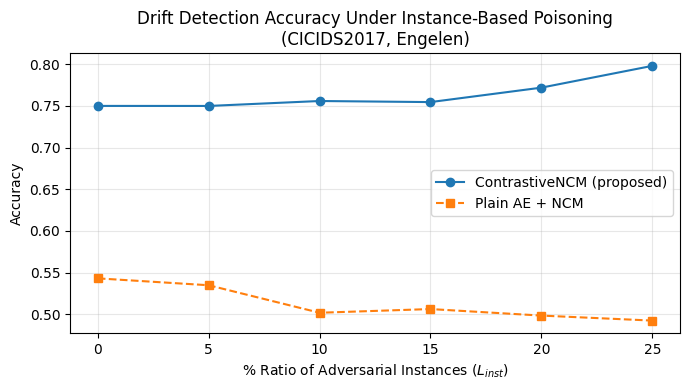

In [10]:
import matplotlib.pyplot as plt

pct_vals = [r['l_inst'] * 100 for r in results]

plot_cfg = {
    'ContrastiveNCM': dict(marker='o', ls='-',  label='ContrastiveNCM (proposed)'),
    'Plain AE NCM':   dict(marker='s', ls='--', label='Plain AE + NCM'),
}

plt.figure(figsize=(7, 4))
for m, style in plot_cfg.items():
    plt.plot(pct_vals, [r[m] for r in results], **style)

plt.xlabel('% Ratio of Adversarial Instances ($L_{inst}$)')
plt.ylabel('Accuracy')
plt.title('Drift Detection Accuracy Under Instance-Based Poisoning\n(CICIDS2017, Engelen)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()